# Apply BACK SVM — Remove Background Patches from All Datasets

Applies the trained BACK SVM to:
1. **TCGA** — uses existing merged_output.csv (color stats already computed)
2. **PAIP** — uses existing merged_output.csv (color stats already computed)
3. **CRC-100K** — extracts color stats on-the-fly from raw images

**Label convention:** 0 = Tissue (keep), 1 = Background (remove)

## 1. Load Model

In [1]:
import os
import pandas as pd
import numpy as np
from PIL import Image
import joblib
from tqdm import tqdm

svm_model = joblib.load('svm_model.pkl')
scaler    = joblib.load('scaler.pkl')
FEATURE_COLS = joblib.load('feature_cols.pkl')

print("Model loaded.")
print(f"Features: {FEATURE_COLS}")

Model loaded.
Features: ['avg_R', 'avg_G', 'avg_B', 'std_R', 'std_G', 'std_B']


## 2. Apply to TCGA

In [2]:
TCGA_CSV    = r"D:\Aamir Gulzar\KSA_project2\dataset\merged_output.csv"
TCGA_OUTPUT = r"D:\Aamir Gulzar\KSA_project2\dataset\tcga_clean_no_back.csv"

tcga_df = pd.read_csv(TCGA_CSV)
print(f"TCGA loaded: {len(tcga_df):,} patches")

X_tcga = tcga_df[FEATURE_COLS].values
X_tcga_scaled = scaler.transform(X_tcga)
tcga_df['bg_pred'] = svm_model.predict(X_tcga_scaled)

n_bg   = (tcga_df['bg_pred'] == 1).sum()
n_keep = (tcga_df['bg_pred'] == 0).sum()
print(f"  Background (removed): {n_bg:,}  ({n_bg/len(tcga_df)*100:.2f}%)")
print(f"  Tissue    (kept):     {n_keep:,}  ({n_keep/len(tcga_df)*100:.2f}%)")

tcga_clean = tcga_df[tcga_df['bg_pred'] == 0].drop(columns=['bg_pred'])
tcga_clean.to_csv(TCGA_OUTPUT, index=False)
print(f"\nSaved to: {TCGA_OUTPUT}")

TCGA loaded: 1,459,999 patches
  Background (removed): 104,420  (7.15%)
  Tissue    (kept):     1,355,579  (92.85%)

Saved to: D:\Aamir Gulzar\KSA_project2\dataset\tcga_clean_no_back.csv


## 3. Apply to PAIP

In [3]:
PAIP_CSV    = r"D:\Aamir Gulzar\KSA_project2\paip_data\merged_output.csv"
PAIP_OUTPUT = r"D:\Aamir Gulzar\KSA_project2\paip_data\paip_clean_no_back.csv"

paip_df = pd.read_csv(PAIP_CSV)
print(f"PAIP loaded: {len(paip_df):,} patches")

X_paip = paip_df[FEATURE_COLS].values
X_paip_scaled = scaler.transform(X_paip)
paip_df['bg_pred'] = svm_model.predict(X_paip_scaled)

n_bg   = (paip_df['bg_pred'] == 1).sum()
n_keep = (paip_df['bg_pred'] == 0).sum()
print(f"  Background (removed): {n_bg:,}  ({n_bg/len(paip_df)*100:.2f}%)")
print(f"  Tissue    (kept):     {n_keep:,}  ({n_keep/len(paip_df)*100:.2f}%)")

paip_clean = paip_df[paip_df['bg_pred'] == 0].drop(columns=['bg_pred'])
paip_clean.to_csv(PAIP_OUTPUT, index=False)
print(f"\nSaved to: {PAIP_OUTPUT}")

PAIP loaded: 272,414 patches
  Background (removed): 4,859  (1.78%)
  Tissue    (kept):     267,555  (98.22%)

Saved to: D:\Aamir Gulzar\KSA_project2\paip_data\paip_clean_no_back.csv


## 4. Extract Color Stats from CRC-100K

In [4]:
CRC_ROOT      = r"D:\Aamir Gulzar\dataset\CRC100K\NCT-CRC-HE-100K-NONORM"
CRC_STATS_CSV = r"D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\data_cleaning\BG_SVM_training\crc100k_statistics.csv"

IMG_EXTS = ('.tif', '.tiff', '.png', '.jpg', '.jpeg')

def extract_features(image_path):
    img = np.array(Image.open(image_path).convert("RGB"))
    return [
        img[:, :, 0].mean(), img[:, :, 1].mean(), img[:, :, 2].mean(),
        img[:, :, 0].std(),  img[:, :, 1].std(),  img[:, :, 2].std()
    ]


class_folders = sorted([
    f for f in os.listdir(CRC_ROOT)
    if os.path.isdir(os.path.join(CRC_ROOT, f))
])
print(f"CRC-100K classes ({len(class_folders)}): {class_folders}")

rows = []

for cls in class_folders:
    folder = os.path.join(CRC_ROOT, cls)
    files  = [f for f in os.listdir(folder) if f.lower().endswith(IMG_EXTS)]

    for fname in tqdm(files, desc=cls, leave=False):
        fpath = os.path.join(folder, fname)
        try:
            feats = extract_features(fpath)
            rows.append([fpath, fname, cls] + feats)
        except Exception as e:
            print(f"  Error: {fpath}: {e}")

crc_df = pd.DataFrame(
    rows,
    columns=['patch_location', 'patch_name', 'crc_class'] + FEATURE_COLS
)
crc_df.to_csv(CRC_STATS_CSV, index=False)
print(f"\nExtracted stats for {len(crc_df):,} patches")
print(f"Saved to: {CRC_STATS_CSV}")
print("\nPatch count per class:")
print(crc_df['crc_class'].value_counts().to_string())

CRC-100K classes (9): ['ADI', 'BACK', 'DEB', 'LYM', 'MUC', 'MUS', 'NORM', 'STR', 'TUM']



Extracted stats for 100,000 patches
Saved to: D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\data_cleaning\BG_SVM_training\crc100k_statistics.csv

Patch count per class:
crc_class
TUM     14317
MUS     13536
LYM     11557
DEB     11512
BACK    10566
STR     10446
ADI     10407
MUC      8896
NORM     8763


## 5. Apply SVM to CRC-100K

In [5]:
CRC_OUTPUT = r"D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\data_cleaning\BG_SVM_training\crc100k_clean_no_back.csv"

# Re-load if needed (skip if already in memory)
if 'crc_df' not in dir() or crc_df is None:
    crc_df = pd.read_csv(CRC_STATS_CSV)

X_crc = crc_df[FEATURE_COLS].values
X_crc_scaled = scaler.transform(X_crc)
crc_df['bg_pred'] = svm_model.predict(X_crc_scaled)

print("Per-class prediction summary:")
summary = crc_df.groupby('crc_class')['bg_pred'].value_counts().unstack(fill_value=0)
summary.columns = ['Tissue', 'Background']
summary['Total'] = summary.sum(axis=1)
summary['BG%'] = (summary['Background'] / summary['Total'] * 100).round(2)
print(summary.to_string())

total_bg   = (crc_df['bg_pred'] == 1).sum()
total_keep = (crc_df['bg_pred'] == 0).sum()
print(f"\nTotal background (removed): {total_bg:,}  ({total_bg/len(crc_df)*100:.2f}%)")
print(f"Total tissue    (kept):     {total_keep:,}  ({total_keep/len(crc_df)*100:.2f}%)")

Per-class prediction summary:
           Tissue  Background  Total    BG%
crc_class                                  
ADI          5238        5169  10407  49.67
BACK          104       10462  10566  99.02
DEB         11316         196  11512   1.70
LYM         11325         232  11557   2.01
MUC          8831          65   8896   0.73
MUS         13519          17  13536   0.13
NORM         8762           1   8763   0.01
STR         10446           0  10446   0.00
TUM         14317           0  14317   0.00

Total background (removed): 16,142  (16.14%)
Total tissue    (kept):     83,858  (83.86%)


In [6]:
crc_clean = crc_df[crc_df['bg_pred'] == 0].drop(columns=['bg_pred'])
crc_clean.to_csv(CRC_OUTPUT, index=False)
print(f"Saved {len(crc_clean):,} CRC-100K tissue patches to:")
print(f"  {CRC_OUTPUT}")

Saved 83,858 CRC-100K tissue patches to:
  D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\data_cleaning\BG_SVM_training\crc100k_clean_no_back.csv


## 6. Ground-Truth Validation on CRC-100K

CRC-100K has known class labels, so we can directly measure how well the SVM performs:
- **Recall on BACK** — of all true BACK patches, what fraction did the SVM catch?
- **False positive rate per class** — of all true tissue patches, what fraction was wrongly removed?

This is a free sanity check before trusting the model on TCGA/PAIP where no ground truth exists.

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Ground truth: BACK class = 1, everything else = 0
y_true = (crc_df['crc_class'] == 'BACK').astype(int).values
y_pred = crc_df['bg_pred'].values

TP = ((y_pred == 1) & (y_true == 1)).sum()
FN = ((y_pred == 0) & (y_true == 1)).sum()
FP = ((y_pred == 1) & (y_true == 0)).sum()
TN = ((y_pred == 0) & (y_true == 0)).sum()

recall_back = TP / (TP + FN) if (TP + FN) > 0 else 0
fpr_tissue  = FP / (FP + TN) if (FP + TN) > 0 else 0
precision   = TP / (TP + FP) if (TP + FP) > 0 else 0

print("=" * 45)
print("CRC-100K Ground-Truth Validation")
print("=" * 45)
print(f"  BACK recall  (caught / all BACK):  {recall_back*100:.2f}%  ({TP:,} / {TP+FN:,})")
print(f"  Precision    (BACK / all flagged): {precision*100:.2f}%  ({TP:,} / {TP+FP:,})")
print(f"  Tissue FPR   (wrongly removed):    {fpr_tissue*100:.2f}%  ({FP:,} / {FP+TN:,})")

CRC-100K Ground-Truth Validation
  BACK recall  (caught / all BACK):  99.02%  (10,462 / 10,566)
  Precision    (BACK / all flagged): 64.81%  (10,462 / 16,142)
  Tissue FPR   (wrongly removed):    6.35%  (5,680 / 89,434)


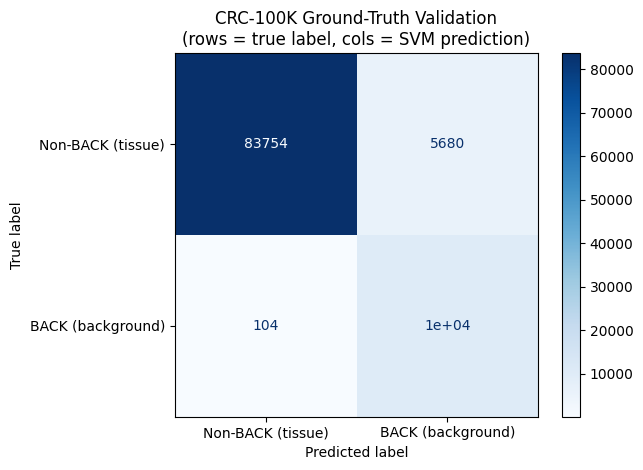

In [8]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Non-BACK (tissue)', 'BACK (background)']
)
disp.plot(cmap='Blues')
plt.title('CRC-100K Ground-Truth Validation\n(rows = true label, cols = SVM prediction)')
plt.tight_layout()
plt.show()

False positive rate per non-BACK class:
           flagged  total    FP%
crc_class                       
ADI           5169  10407  49.67
LYM            232  11557   2.01
DEB            196  11512   1.70
MUC             65   8896   0.73
MUS             17  13536   0.13
NORM             1   8763   0.01
STR              0  10446   0.00
TUM              0  14317   0.00


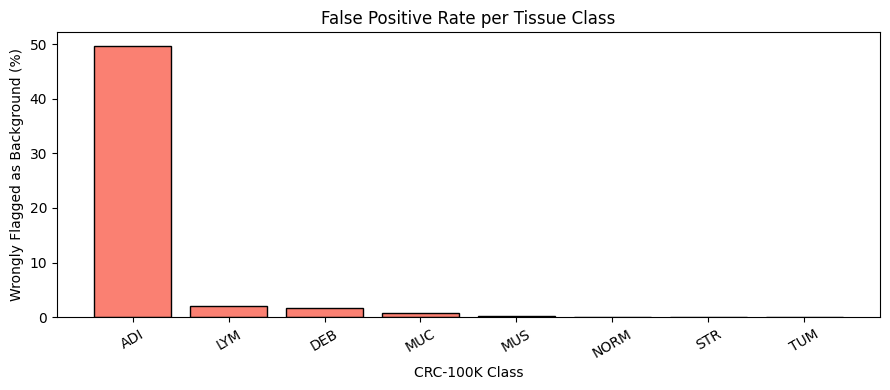

In [9]:
# Per-class false positive rate — shows which tissue classes are most at risk of over-removal
non_back = crc_df[crc_df['crc_class'] != 'BACK'].copy()

fp_by_class = (
    non_back.groupby('crc_class')['bg_pred']
    .agg(flagged=lambda x: (x == 1).sum(), total='count')
)
fp_by_class['FP%'] = (fp_by_class['flagged'] / fp_by_class['total'] * 100).round(2)
fp_by_class = fp_by_class.sort_values('FP%', ascending=False)

print("False positive rate per non-BACK class:")
print(fp_by_class.to_string())

plt.figure(figsize=(9, 4))
plt.bar(fp_by_class.index, fp_by_class['FP%'], color='salmon', edgecolor='black')
plt.xlabel('CRC-100K Class')
plt.ylabel('Wrongly Flagged as Background (%)')
plt.title('False Positive Rate per Tissue Class')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 7. Summary

In [10]:
print("=" * 50)
print("BACK SVM Filtering Summary")
print("=" * 50)

datasets = [
    ("TCGA",    TCGA_OUTPUT),
    ("PAIP",    PAIP_OUTPUT),
    ("CRC-100K", CRC_OUTPUT),
]

for name, path in datasets:
    df_out = pd.read_csv(path)
    print(f"  {name}: {len(df_out):,} tissue patches → {path}")

BACK SVM Filtering Summary
  TCGA: 1,355,579 tissue patches → D:\Aamir Gulzar\KSA_project2\dataset\tcga_clean_no_back.csv
  PAIP: 267,555 tissue patches → D:\Aamir Gulzar\KSA_project2\paip_data\paip_clean_no_back.csv
  CRC-100K: 83,858 tissue patches → D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\data_cleaning\BG_SVM_training\crc100k_clean_no_back.csv
